In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
from tqdm import tqdm

from typing import Literal
from scipy.signal import convolve

import sys, os
sys.path.append(os.path.join(os.getcwd(), "../ml-force"))


np.random.seed(1)
torch.manual_seed(1)
torch.cuda.manual_seed(1)

from ml_force import MorrisLecar, MorrisLecarCurrent, z_transform, minmax_transform

In [2]:
save_dir = os.path.join(os.getcwd(), "memory_task_with_training", "figures")
os.makedirs(save_dir, exist_ok=True)

print(save_dir)

/home/ali/Code/ml_force_research/morris_lecar/memory_task_with_training/figures


## Create Supervisor as a memory task

#### Helper functions

In [3]:
def smooth(signal, window_len:int=5, window:Literal['hanning', 'hamming', 'bartlett', 'blackman']='flat', 
           mode:Literal['full', 'valid', 'same']='same', axis:int=0, 
           method:Literal['auto', 'direct', 'fft']='auto'):
    """
    Smooth the signal using a window with requested size.
    This method is based on the convolution of a scaled window with the signal.
    The signal is prepared by introducing reflected copies of the signal (with the window size) in both ends
    so that transient parts are minimized in the begining and end part of the output signal.
    """
    if signal.ndim != 2:
        raise ValueError("Signal must be 2D")
    if window_len < 3:
        return signal
    if signal.shape[axis] < window_len:
        raise ValueError("Input signal must be longer than window size")
    if window == 'flat':
        kernel = np.ones(window_len) / window_len
    else:
        kernel = eval(f"np.{window}(window_len)")
    if axis==0:
        kernel_nd = kernel[:, np.newaxis]
    elif axis==1:
        kernel_nd = kernel[np.newaxis, :]
    else:
        raise ValueError("Axis must be 0 or 1")
    return convolve(signal, kernel_nd / kernel_nd.sum(), mode=mode, method=method)

#### Image generation

Random duration of several images

In [4]:
def add_noise_to_image(image:np.ndarray, noise_level:float=0.1):
    n_pixels = int(noise_level * image.size)
    noise_pixels = np.random.choice(np.arange(image.size), size=n_pixels, replace=False)
    new_image = image.copy().ravel()
    new_image[noise_pixels] *= -1
    return new_image.reshape(image.shape)

In [5]:
multiplier = 1
n_images = 5
width, height = 5, 5

noise_level = 0.1

images = np.array([np.random.choice([-1, 1], size=(height, width), replace=True) for _ in range(n_images)]) * multiplier
corrupted_images = np.array([add_noise_to_image(image, noise_level=noise_level) for image in images])

In [6]:
# Test to see if ravel() and reshape() are inverses

ind = 2
print(np.sum(images[ind] == images[ind].ravel().reshape(height, width)) == width * height)

True


In [7]:
# Test to see if images are unique

for i in range(n_images):
    for j in range(i+1, n_images):
        if np.sum(images[i] == images[j]) == width * height:
            print(i, j)
        elif np.sum(corrupted_images[i] == corrupted_images[j]) == width * height:
            print(i, j)

In [8]:
def unravel_image(image, height:int, width:int):
    return image.ravel().reshape(height, width)

In [9]:
print(images[2])

[[-1  1 -1 -1  1]
 [ 1  1 -1  1 -1]
 [-1  1  1 -1  1]
 [ 1  1  1 -1 -1]
 [ 1  1 -1 -1 -1]]


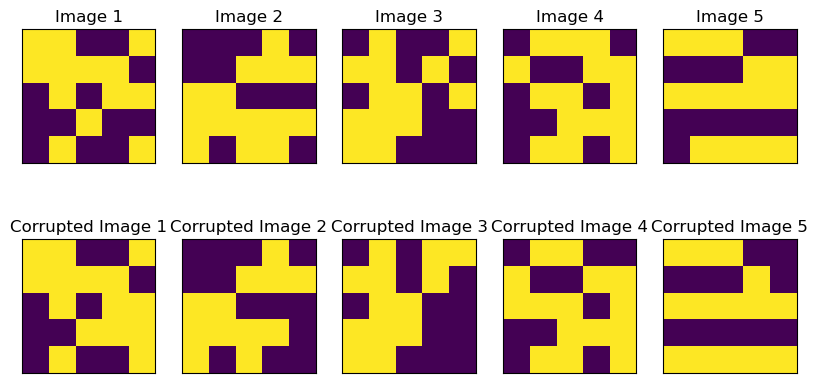

In [10]:
fig, ax = plt.subplots(figsize=(2 * n_images, 5), ncols=n_images, nrows=2)

for i in range(ax.shape[1]):
    ax[0, i].imshow(images[i])
    ax[0, i].set_title(f"Image {i+1}")
    ax[0, i].set_xticks([])
    ax[0, i].set_yticks([])
    ax[1, i].imshow(corrupted_images[i])
    ax[1, i].set_title(f"Corrupted Image {i+1}")
    ax[1, i].set_xticks([])
    ax[1, i].set_yticks([])
plt.show()

In [11]:
dt = 0.05   # ms
n_exposures = 30     # number of images shown
nt_min = 3000 // dt
nt_max = 4000 // dt

t_transient = 1500  # ms
nt_transient = int(t_transient // dt)

signal = []
exposures = []
noisy_images = []
noisy_signal = []
time_stamps = []
for i in range(n_exposures):
    signal += [np.zeros(height * width) for _ in range(nt_transient)]   # show a blank screen for `t_transient` ms
    noisy_signal += [np.zeros(height * width) for _ in range(nt_transient)]   # show a blank screen for `t_transient` ms
    nt = np.random.randint(nt_min, nt_max)  # number of time steps to show the image
    # print(round(nt * dt, ndigits=2))
    image_index = np.random.randint(0, n_images)
    exposures.append(image_index)       # save the image index for each exposure
    image_raveled = images[image_index].ravel()   # ravel the image
    noisy_image_raveled = corrupted_images[image_index].ravel()   # ravel the image
    noisy_images.append(noisy_image_raveled)
    signal += [image_raveled for _ in range(nt)]    # show the image for nt time steps
    noisy_signal += [noisy_image_raveled for _ in range(nt)]    # show the image for nt time steps
    time_stamps.append(len(signal) - int(1000 // dt))    # save the time stamp for each exposure

signal = np.array(signal)
noisy_signal = np.array(noisy_signal)

print(signal.shape, noisy_signal.shape, len(time_stamps))
print(time_stamps)
print(f"Total signal length: {signal.shape[0]} --> {(signal.shape[0] * dt):.2f} ms")
print(f"Exposures: {np.unique(exposures)}")

(3058470, 25) (3058470, 25) 30
[87051, 194744, 297252, 400698, 506088, 601802, 708775, 815989, 911318, 1010645, 1102735, 1203639, 1302220, 1410057, 1512633, 1608666, 1710651, 1811305, 1913295, 2018841, 2117176, 2221292, 2317892, 2427576, 2530934, 2627010, 2730662, 2834749, 2929918, 3038471]
Total signal length: 3058470 --> 152923.50 ms
Exposures: [0 1 2 3 4]


In [12]:
window_len = 300 // dt

smoothing_params = {
    "window_len": window_len,
    "window": 'hanning',
    "mode": 'same',
    "method": 'fft',
    "axis": 0
}
signal_smoothed = smooth(signal, **smoothing_params)
noisy_signal_smoothed = smooth(noisy_signal, **smoothing_params)

/home/ali/Apps/anaconda3/envs/ml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


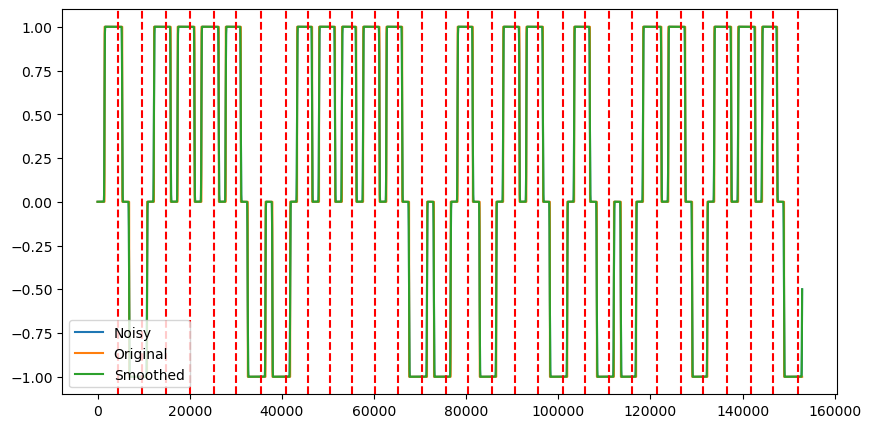

In [15]:
t_train = np.arange(signal.shape[0]) * dt

pixel = 5
plt.figure(figsize=(10, 5))
plt.plot(t_train, noisy_signal_smoothed[:, pixel], label="Noisy")
plt.plot(t_train, signal[:, pixel], label="Original")
plt.plot(t_train, signal_smoothed[:, pixel], label="Smoothed")
for i in range(len(time_stamps)):
    plt.axvline(time_stamps[i] * dt, color='r', linestyle='--')
plt.legend()
plt.show()

## Instantiate the ML class

In [16]:
N = 500
T = signal_smoothed.shape[0] * dt
I_bias = 65      # mA

Q = 50
gbar = 20   # nS
lamda = 0.8
p_sparsity = 0.1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

ml = MorrisLecarCurrent(supervisor=signal_smoothed, N=N, T=T, dt=dt, BIAS=I_bias, Q=Q, gbar=gbar, 
                 p_sparsity=p_sparsity,
                 l=lamda, device=device)

cuda


## Training

#### Helper Functions for save and load of the model params

In [17]:
def save_reservoir_state(ml:MorrisLecar, save_prefix:str=None):
    """Save the reservoir state, including n, s, eta, and dec.
    Also save the images and exposures shown to the reservoir.
    """
    if save_prefix is None:
        save_prefix = ""
        
    save_dir = os.path.join(os.getcwd(), "memory_task", "reservoir_states" + save_prefix)
    os.makedirs(save_dir, exist_ok=True)
    
    np.save(os.path.join(save_dir, "v.npy"), ml.v.cpu().numpy())
    np.save(os.path.join(save_dir, "n.npy"), ml.n.cpu().numpy())
    np.save(os.path.join(save_dir, "s.npy"), ml.s.cpu().numpy())
    np.save(os.path.join(save_dir, "eta.npy"), ml.eta.cpu().numpy())
    np.save(os.path.join(save_dir, "dec.npy"), ml.dec.cpu().numpy())
    np.save(os.path.join(save_dir, "images.npy"), images)
    np.save(os.path.join(save_dir, "exposures.npy"), exposures)
    
    return

In [18]:
def load_model(ml: MorrisLecar, load_prefix:str=None):
    if load_prefix is None:
        load_prefix = ""
        
    save_dir = os.path.join(os.getcwd(), "memory_task", "reservoir_states" + load_prefix)
    
    ml.v = torch.from_numpy(np.load(os.path.join(save_dir, "v.npy"))).to(device)
    ml.n = torch.from_numpy(np.load(os.path.join(save_dir, "n.npy"))).to(device)
    ml.s = torch.from_numpy(np.load(os.path.join(save_dir, "s.npy"))).to(device)
    ml.eta = torch.from_numpy(np.load(os.path.join(save_dir, "eta.npy"))).to(device)
    ml.dec = torch.from_numpy(np.load(os.path.join(save_dir, "dec.npy"))).to(device)
    images = np.load(os.path.join(save_dir, "images.npy"))
    exposures = np.load(os.path.join(save_dir, "exposures.npy"))
    
    return ml, images, exposures

#### Train

Give the system a noisy version of the supervisor as the input using `ml.eta @ sup_with_noise`.\
Do RLS with the original supervisor.

In [19]:
nt = ml.sup.shape[0]

transient_time = 500
nt_transient = int(transient_time // dt)
noisy_sup_tensor = torch.tensor(noisy_signal_smoothed, dtype=torch.float32, device=device)

s_rec = torch.zeros((ml._N, 1), dtype=torch.float32, device=device)
n_rec = torch.zeros((ml._N, 1), dtype=torch.float32, device=device)
v_rec = torch.zeros((ml._N, 1), dtype=torch.float32, device=device)

print("transient time:", transient_time)
for i in tqdm(range(nt_transient)):
    ml.euler_step(closed_loop=True)

print(f"Training Time: {round(ml.sup.shape[0]*ml._dt, ndigits=2)} ms")
for i in tqdm(range(nt)):
    ml._BIAS = I_bias + ml.eta @ noisy_sup_tensor[i].reshape(-1, 1)
    ml.euler_step(closed_loop=True, voltage_bound=None)
    ml.x_hat_rec[i] = ml.x_hat.ravel()
    
    # Save the reservoir state at the time stamps
    if i % 20 == 1:
        ml.rls(i)

s_rec = ml.s.clone().detach()
n_rec = ml.n.clone().detach()
v_rec = ml.v.clone().detach()


transient time: 500


100%|██████████| 9999/9999 [00:02<00:00, 3415.51it/s]


Training Time: 152923.5 ms


100%|██████████| 3058470/3058470 [16:27<00:00, 3096.82it/s]


In [20]:
# End of training, reset bias to original value
ml._BIAS = I_bias

In [21]:
save_reservoir_state(ml, save_prefix=f"_N{N}_Q{Q}_gbar{gbar}_l{lamda}_p{p_sparsity}")

In [22]:
ml.x_hat_rec.shape, ml.sup.shape

(torch.Size([3058470, 25]), torch.Size([3058470, 25]))

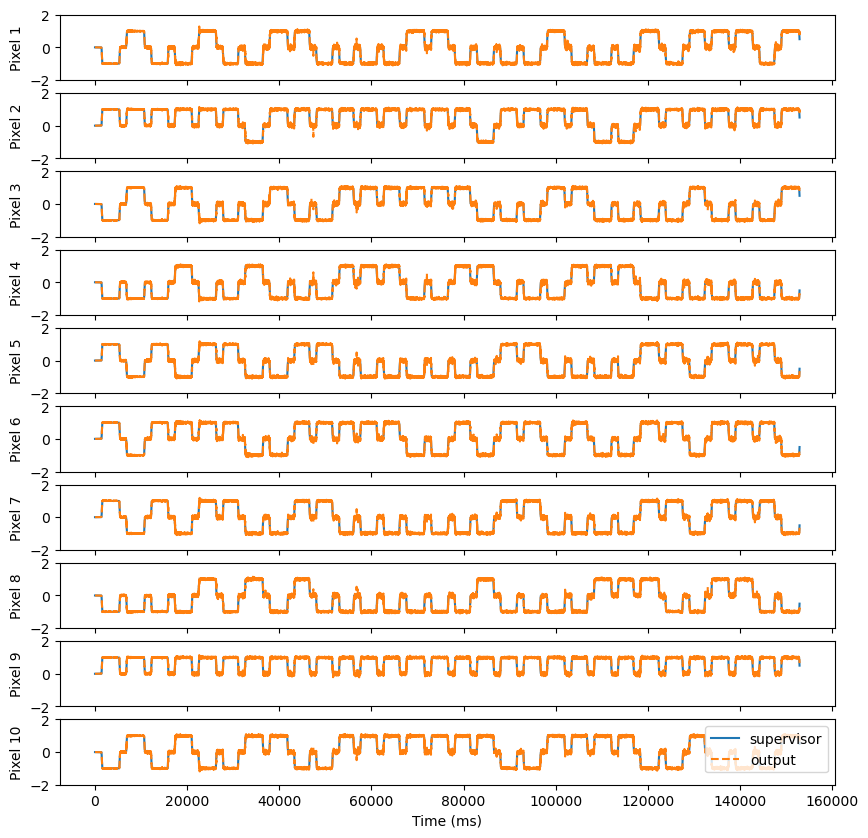

In [23]:
nrows = 10
fig, ax = plt.subplots(figsize=(10, nrows * 1), nrows=nrows, sharex=True, sharey=True)
plt.ylim(-2, 2)

for i in range(len(ax)):
    ax[i].plot(t_train, ml.sup[:, i].cpu().numpy(), label="supervisor")
    ax[i].plot(t_train, ml.x_hat_rec[:, i].cpu().numpy(), '--', label="output")
    ax[i].set_ylabel(f"Pixel {i+1}")
ax[-1].set_xlabel("Time (ms)")
plt.legend()
plt.show()

## Test

### Test by exposing the model to a noisy image

In [ ]:
duration = 2000
nt_transient = int(duration // dt)

ml._BIAS = I_bias + ml.eta @ torch.tensor(noisy_target_image, dtype=torch.float32, device=device)
s_rec = torch.zeros((nt_transient, ml._N), dtype=torch.float32, device=device)  # recording the network state (i.e., synaptic-gating variables)
print("Bringing the network to the new equilibrium...")
for i in tqdm(range(nt_transient)):
    ml.euler_step(closed_loop=False)
    s_rec[i] = ml.s.ravel()

print("Started Testing...")
nt_test = int(duration // dt)
ml._BIAS = I_bias   # reset the bias to the original value
output = torch.zeros((nt_test, target_image.shape[0]), device=device)   # recording the output
for i in tqdm(range(nt_test)):
    ml.euler_step(closed_loop=True, voltage_bound=None)
    output[i] = ml.x_hat.ravel()

### Test by initializing s and v near the equilibrium

In [ ]:
duration = 2000
nt_transient = int(duration // dt)

print(f"Transient Period: {duration} ms")   # transient period
for i in tqdm(range(nt_transient)):
    ml.euler_step(closed_loop=False)

In [ ]:
ml.s = s_rec[exposure].clone().detach().reshape(-1, 1)
ml.v = v_rec[exposure].clone().detach().reshape(-1, 1)
ml.n = n_rec[exposure].clone().detach().reshape(-1, 1)

print(ml.s.max(), ml.s.min())

In [ ]:
print("Started Testing...")
nt_test = int(duration // dt)
output = torch.zeros((nt_test, target_image.shape[0]), device=device)   # recording the output
for i in tqdm(range(nt_test)):
    ml.euler_step(closed_loop=True, voltage_bound=None)
    output[i] = ml.x_hat.ravel()

In [ ]:
t_test = np.arange(nt_test) * dt

nrows = target_image.shape[0] // 10
lw = 1

fig, ax = plt.subplots(figsize=(5, nrows*1), nrows=nrows, sharex=True, sharey=True)
plt.ylim(-2, 2)
plt.suptitle("Results for the Memory Task", y=0.90)
for i in range(len(ax)):
    ax[i].plot(t_test, noisy_target_image[i] * np.ones(nt_test), '--', lw=lw, label="noisy target")
    ax[i].plot(t_test, target_image[i] * np.ones(nt_test), '--', lw=lw, label="target")
    ax[i].plot(t_test, output[:, i].cpu().numpy(), '--', lw=lw, label="output")
    ax[i].set_ylabel(f"Pixel {i+1}")
ax[-1].set_xlabel("Time (ms)")
ax[0].legend(loc='upper right')
plt.savefig(os.path.join(save_dir, "output_series.png"), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
leng = output.shape[0]
model_render = unravel_image(output[-2000:].cpu().numpy().mean(axis=0), height, width)


vmin = min(noisy_target_image.min(), target_image.min(), model_render.min())
vmax = max(noisy_target_image.max(), target_image.max(), model_render.max())

fig, ax = plt.subplots(figsize=(15, 5), ncols=3)
clr1 = ax[0].imshow(unravel_image(noisy_target_image, height, width), vmin=vmin, vmax=vmax)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title("Noisy Image")
clr2 = ax[1].imshow(unravel_image(target_image, height, width), vmin=vmin, vmax=vmax)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title("Target Image")
clr3 = ax[2].imshow(model_render, vmin=vmin, vmax=vmax)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title("Model Render")
plt.colorbar(clr1, ax=ax[0])
plt.colorbar(clr2, ax=ax[1])
plt.colorbar(clr3, ax=ax[2])
plt.suptitle("Memory Task Image Comparison", y=0.97, fontsize=16)
plt.savefig(os.path.join(save_dir, "image_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

plt.imshow(images[exposures[-1]])
plt.title(f"Image {exposures[-1]}")
plt.xticks([])
plt.yticks([])
plt.show()
plt.close()

In [ ]:
exposures[-1]

### Large-scale test

In [24]:
n_tasks = 20
# n_tests = len(exposures)

duration = 3000  # ms
nt = int(duration // dt)

test_exposures = np.random.choice(exposures, size=n_tasks, replace=True)        # randomly select n_tasks images from the exposures
# test_exposures = exposures + exposures  # repeat the exposures
test_exposures = test_exposures[:n_tasks]  # select the first n_tasks images
test_images = np.array([images[img_id].ravel().reshape(-1, 1) for img_id in test_exposures])
corrupted_test_images = np.array([corrupted_images[img_id].ravel().reshape(-1, 1) for img_id in test_exposures])

In [25]:
test_signal = []
curropted_test_signal = []
for i, image_id in enumerate(test_exposures):
    test_signal += [np.zeros((height * width, )) for _ in range(nt_transient)]   # show a blank screen for `t_transient` ms
    curropted_test_signal += [np.zeros((height * width, )) for _ in range(nt_transient)]   # show a blank screen for `t_transient` ms
    # nt = int(1000 // dt)
    test_signal += [test_images[i].ravel() for _ in range(nt)]    # show the image for nt time steps
    curropted_test_signal += [corrupted_test_images[i].ravel() for _ in range(nt)]    # show the image for nt time steps
    
test_signal = np.array(test_signal)
curropted_test_signal = np.array(curropted_test_signal)

print(test_signal.shape, curropted_test_signal.shape)
# print(corrupted_test_images.shape)

(1399960, 25) (1399960, 25)


In [26]:
def rmse (output, target):
    return np.sqrt(np.mean((output - target)**2))

In [27]:
print([rmse(test_images[i], corrupted_test_images[i]) for i in range(n_tasks)])

[0.565685424949238, 0.565685424949238, 0.565685424949238, 0.565685424949238, 0.565685424949238, 0.565685424949238, 0.565685424949238, 0.565685424949238, 0.565685424949238, 0.565685424949238, 0.565685424949238, 0.565685424949238, 0.565685424949238, 0.565685424949238, 0.565685424949238, 0.565685424949238, 0.565685424949238, 0.565685424949238, 0.565685424949238, 0.565685424949238]


In [28]:
test_signal_smoothed = torch.tensor(smooth(test_signal, **smoothing_params), dtype=torch.float32, device=device)
curropted_test_signal_smoothed = torch.tensor(smooth(curropted_test_signal, **smoothing_params), dtype=torch.float32, device=device)

nt_test = test_signal_smoothed.shape[0]
output = torch.zeros((nt_test, ml._N), device=device)   # recording the output

In [29]:

ml.v = v_rec.clone().detach()
ml.s = s_rec.clone().detach()
ml.n = n_rec.clone().detach()


In [30]:
# Calculate the initial state for the network
# ml.s = s_rec[i].clone().detach().reshape(-1, 1)
# ml.n = n_rec[i].clone().detach().reshape(-1, 1)
# ml.v = v_rec[i].clone().detach().reshape(-1, 1)
    
print(f"Testing Period: {(test_signal.shape[0] * dt):.2f} ms")
output = torch.zeros((nt_test, test_images[i].shape[0]), device=device)   # recording the output
for j in tqdm(range(nt_test)):
    ml._BIAS = I_bias + ml.eta @ curropted_test_signal_smoothed[j].reshape(-1, 1) 
    ml.euler_step(closed_loop=True)
    output[j] = ml.x_hat.ravel()

Testing Period: 69998.00 ms


100%|██████████| 1399960/1399960 [07:28<00:00, 3123.53it/s]


In [31]:
renders = []

for i in range(n_tasks):
    model_render = output[(i+1)*nt-6000:(i+1)*nt].cpu().numpy().mean(axis=0)
    renders.append(model_render)

In [32]:
losses = [rmse(test_images[i], renders[i].reshape(-1, 1)) for i in range(len(renders))]
print(f"Average Loss: {np.mean(losses):.4f}")

Average Loss: 0.8030


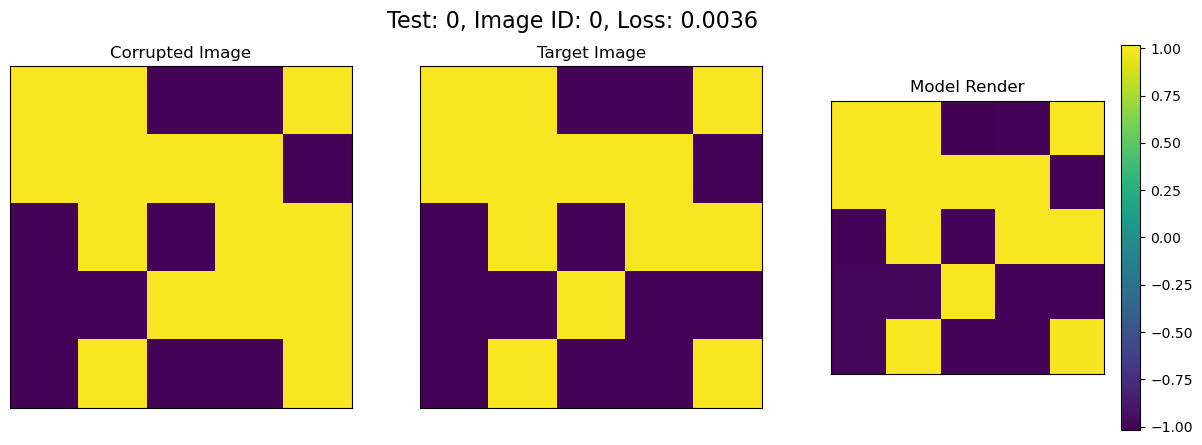

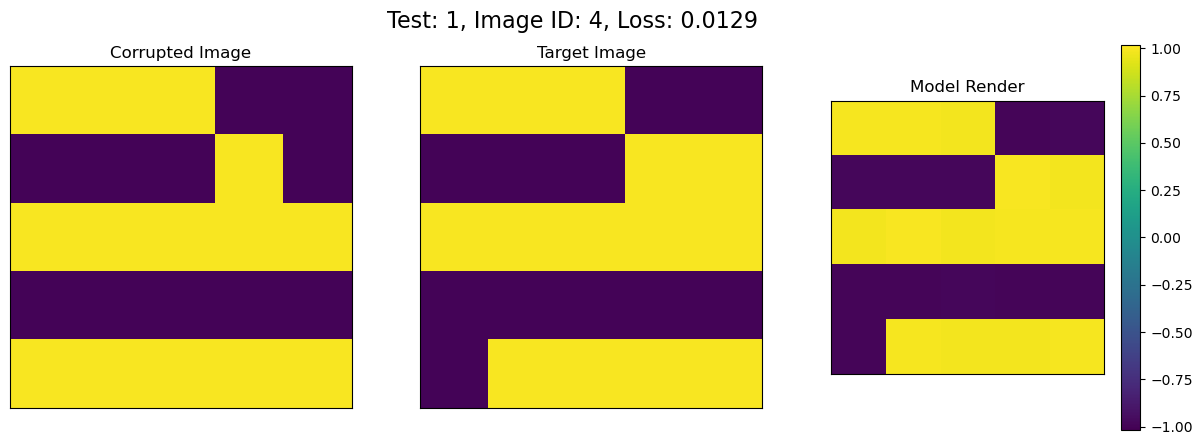

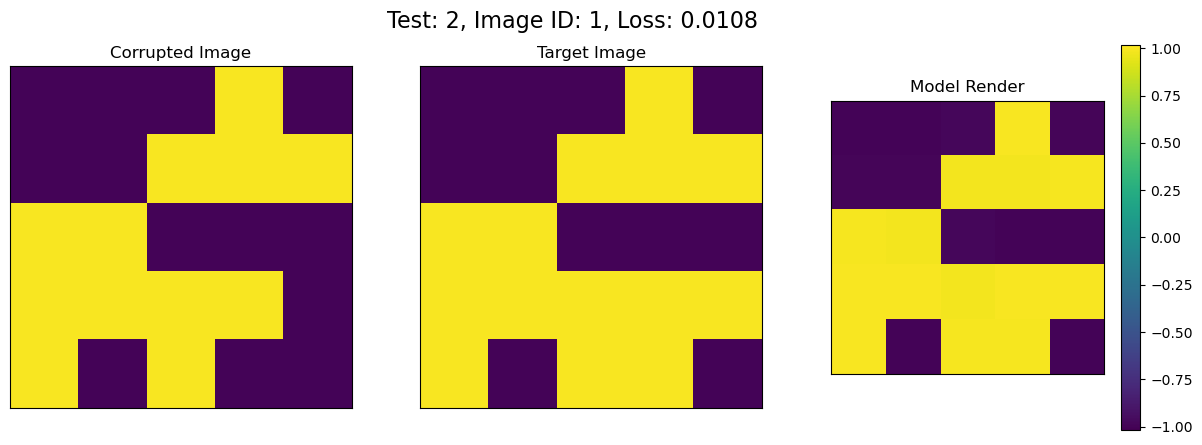

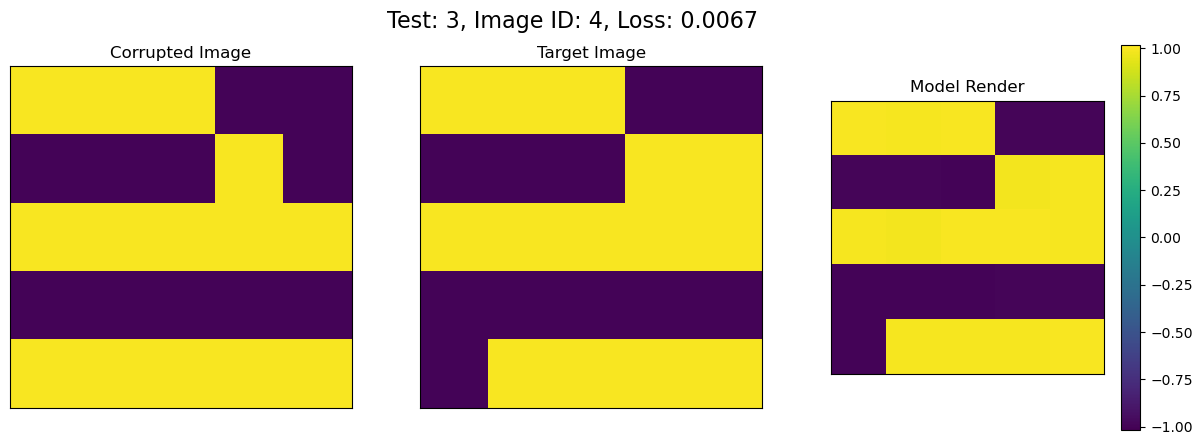

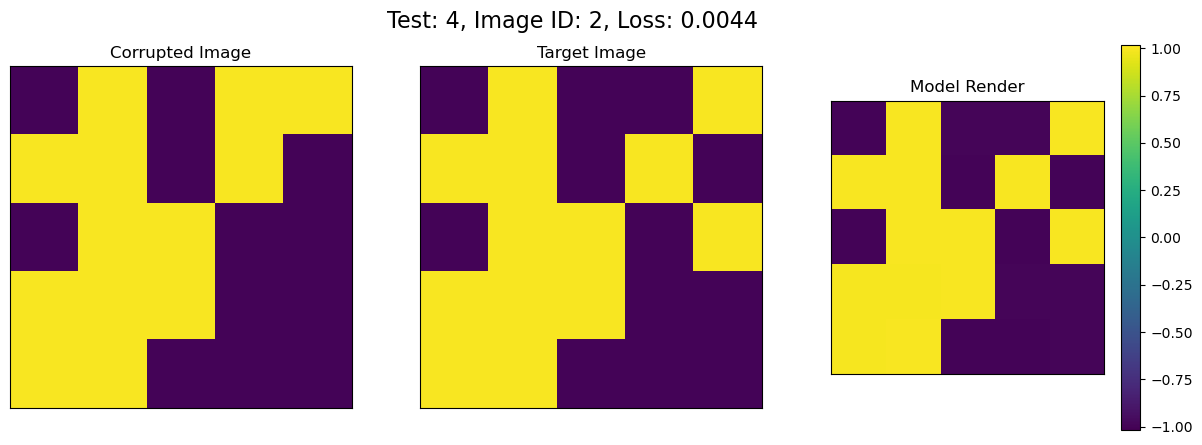

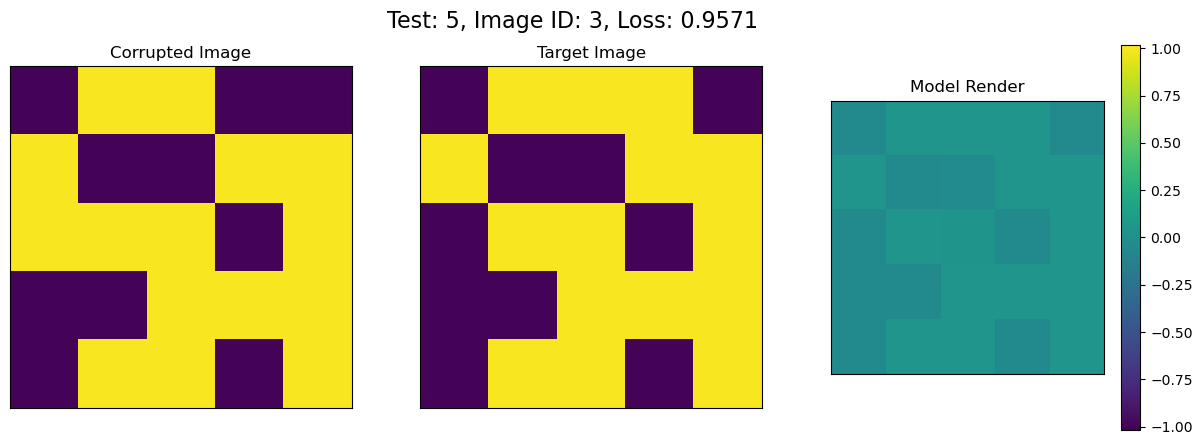

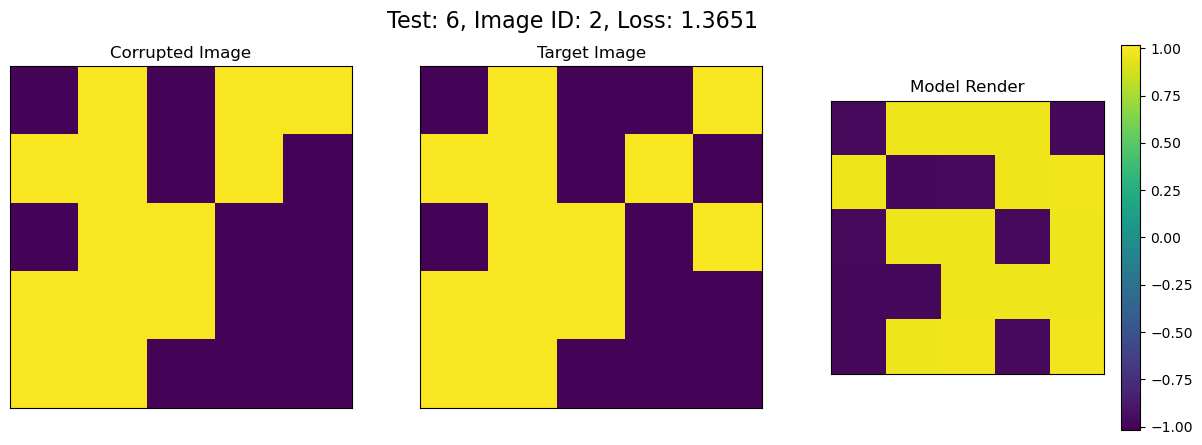

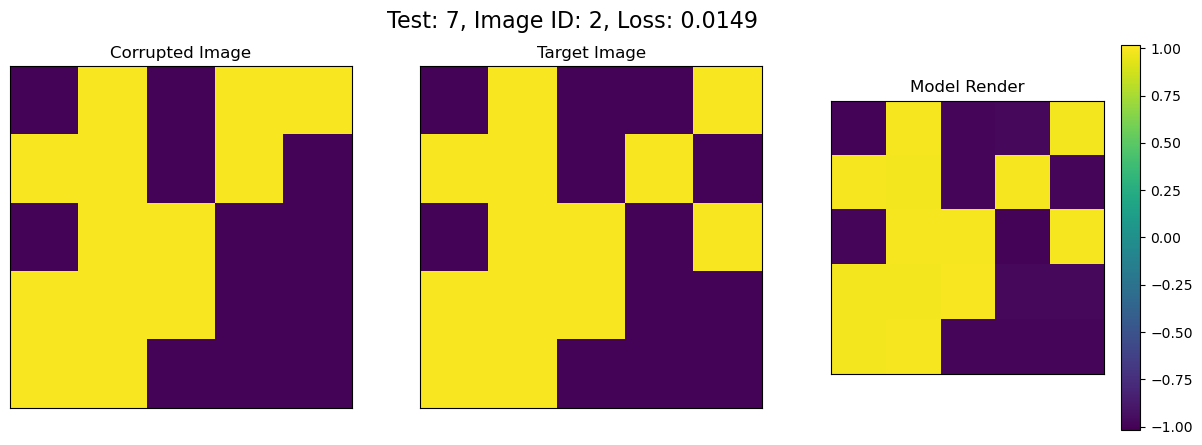

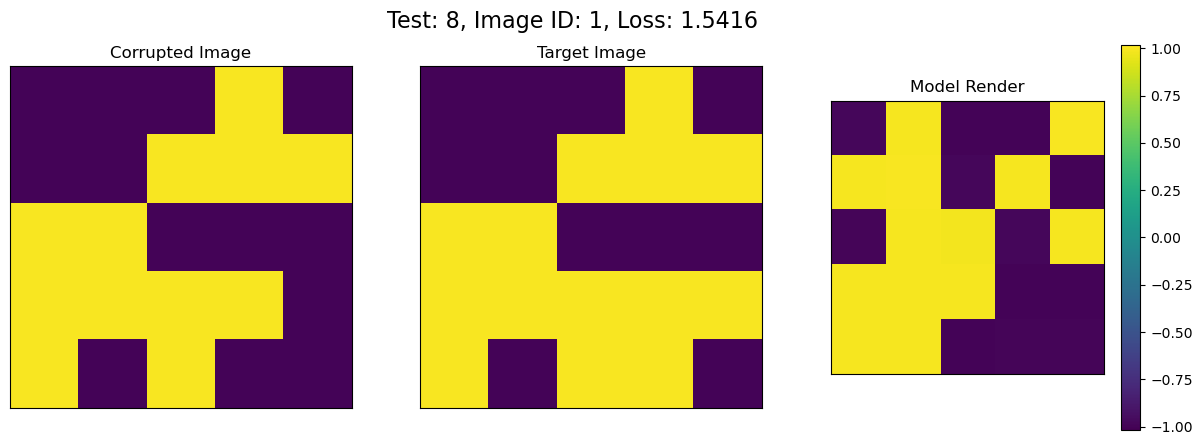

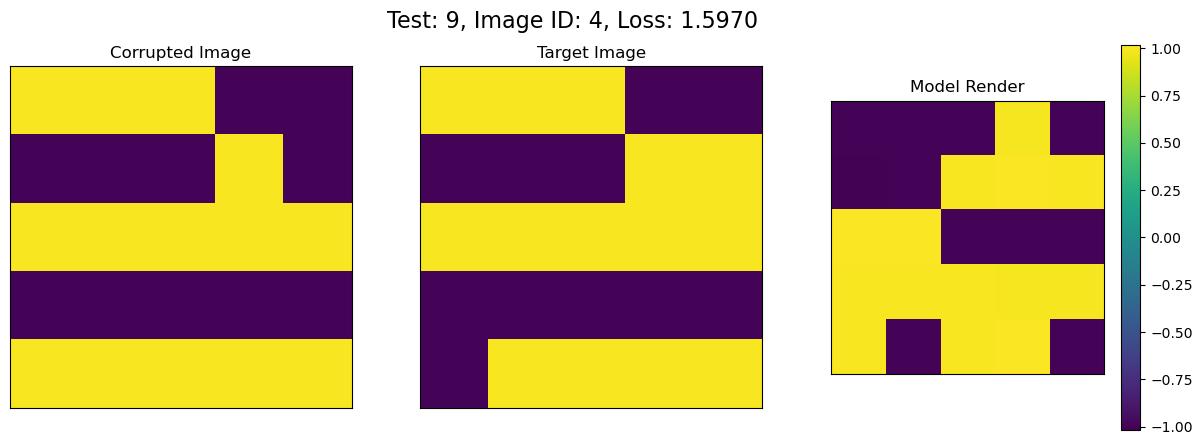

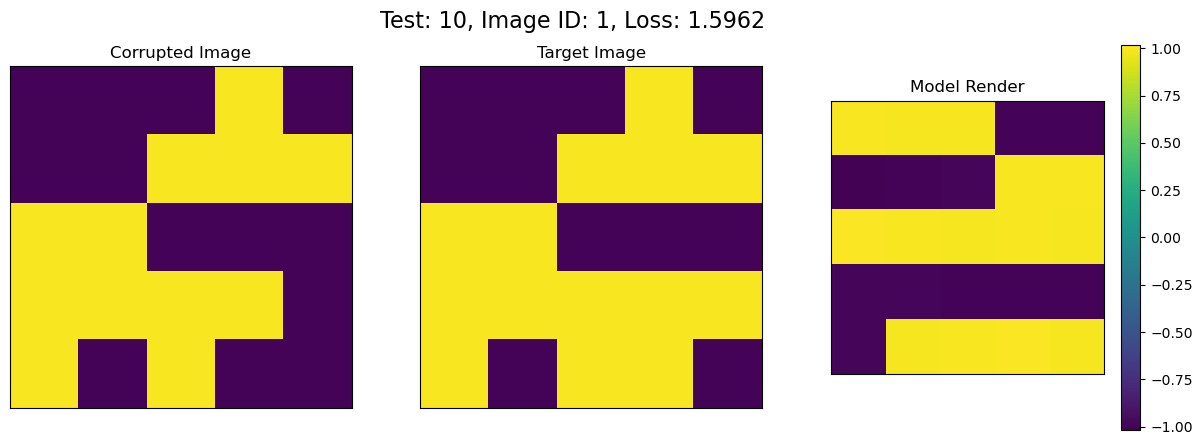

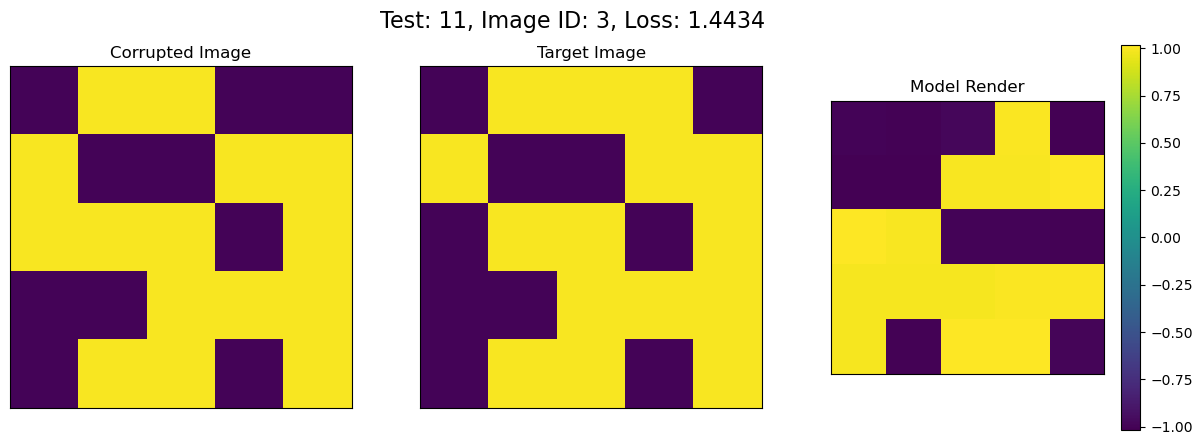

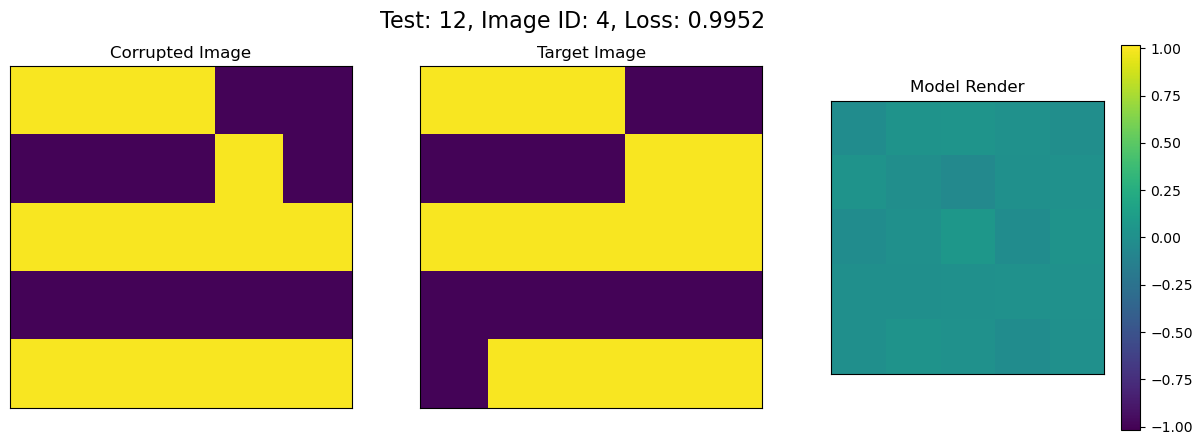

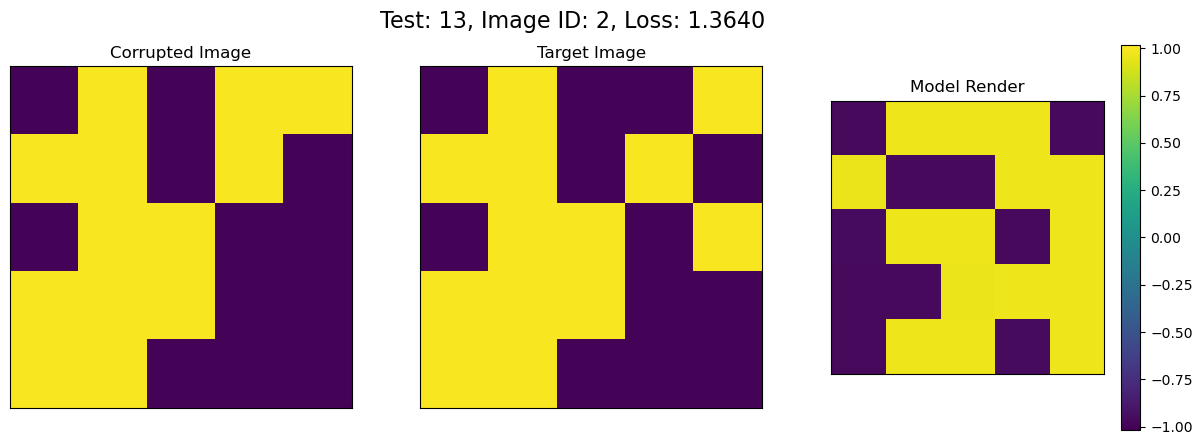

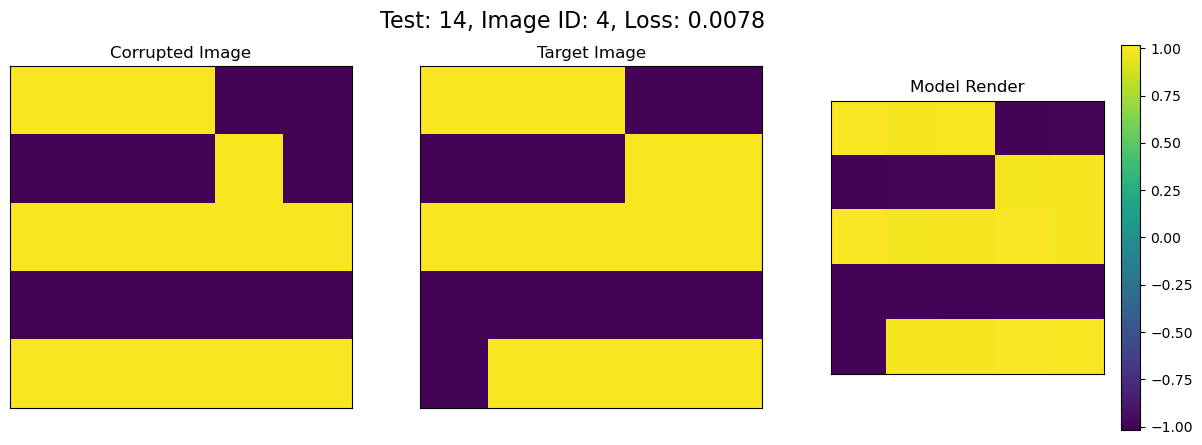

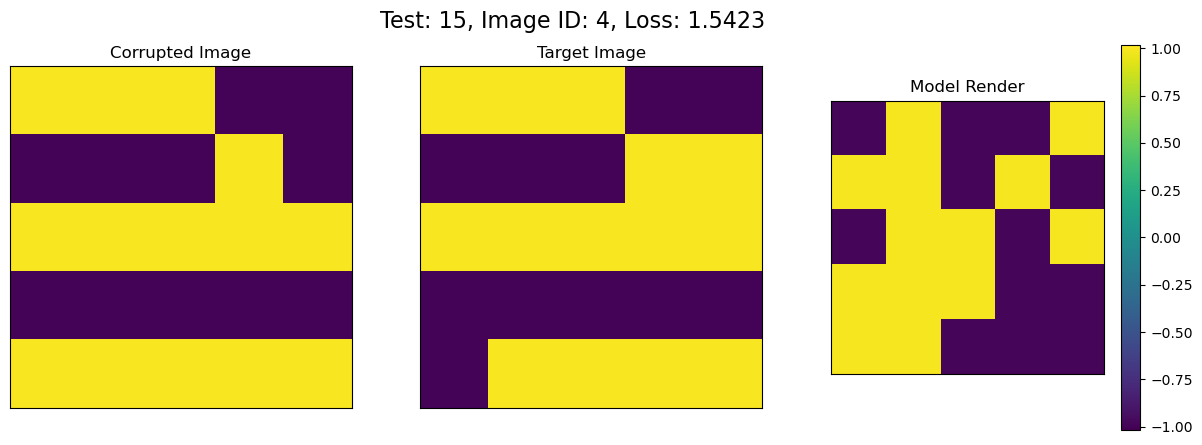

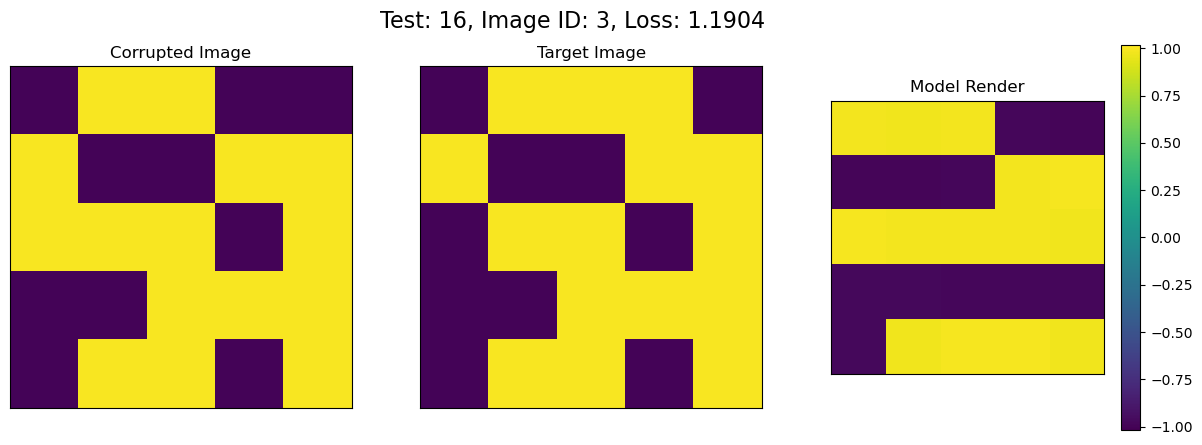

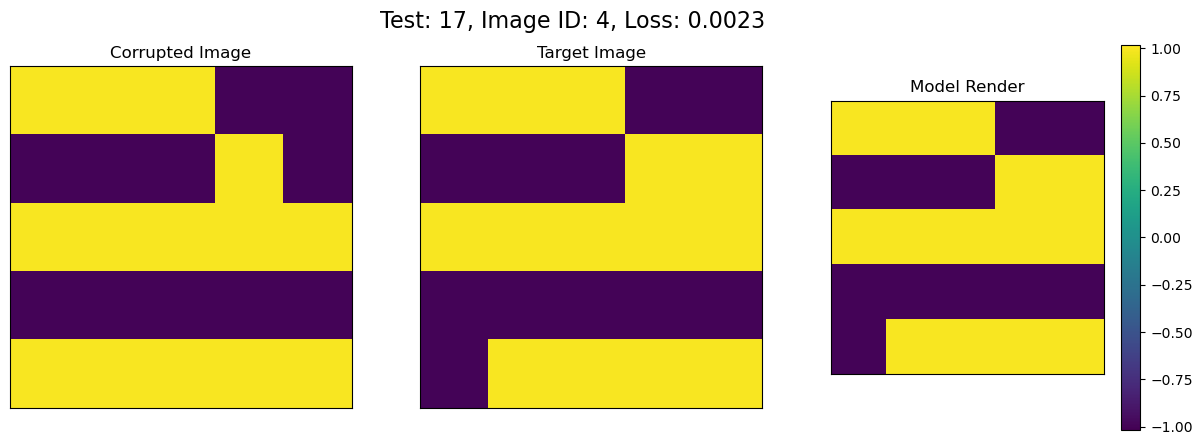

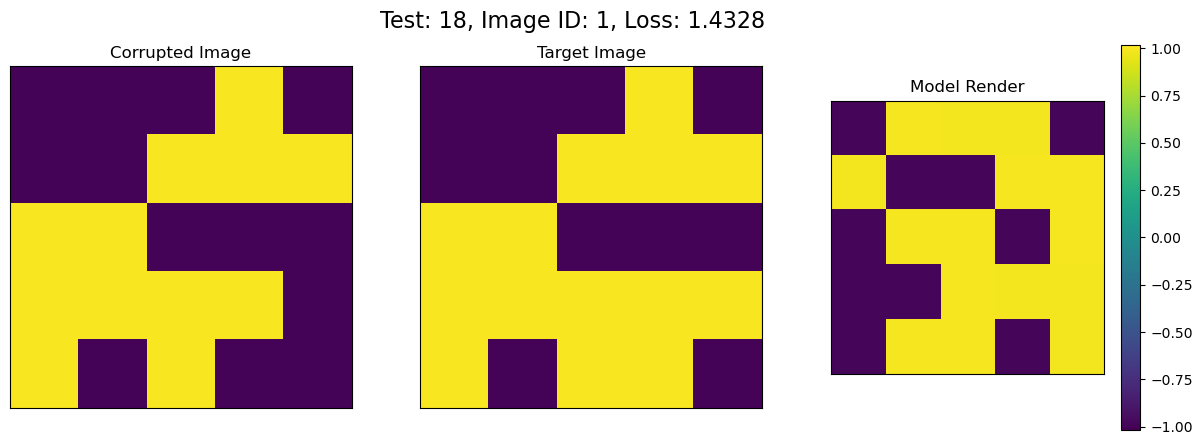

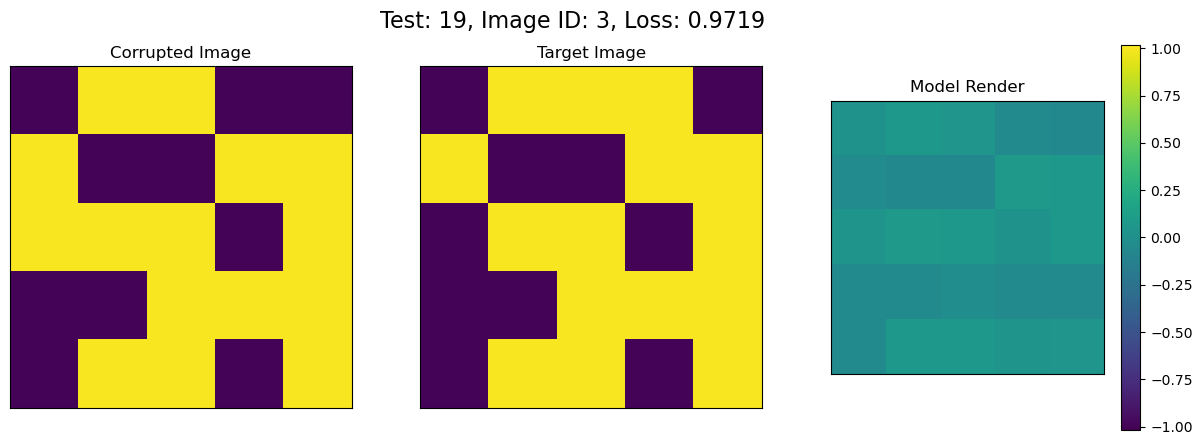

In [33]:
vmin = min(corrupted_test_images.min(), test_images.min(), np.min(renders))
vmax = max(corrupted_test_images.max(), test_images.max(), np.max(renders))

for i in range(len(renders)):
    fig, ax = plt.subplots(figsize=(15, 5), ncols=3)
    clr = ax[0].imshow(unravel_image(corrupted_test_images[i], height, width), vmin=vmin, vmax=vmax)
    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[0].set_title("Corrupted Image")
    ax[1].imshow(unravel_image(test_images[i], height, width), vmin=vmin, vmax=vmax)
    ax[1].set_xticks([])
    ax[1].set_yticks([])
    ax[1].set_title("Target Image")
    ax[2].imshow(unravel_image(renders[i].reshape(-1, 1), height, width), vmin=vmin, vmax=vmax)
    ax[2].set_xticks([])
    ax[2].set_yticks([])
    ax[2].set_title("Model Render")
    plt.colorbar(clr, ax=ax[2])
    plt.suptitle(f"Test: {i}, Image ID: {test_exposures[i]}, Loss: {losses[i]:.4f}", y=0.95, fontsize=16)
    plt.savefig(os.path.join(save_dir, f"image_comparison_{i}.png"), dpi=300, bbox_inches='tight')
    plt.show(fig)
    plt.close(fig)

In [56]:
hits = []
for i in range(len(losses)):
    if losses[i] < .2:
        hits.append((i, test_exposures[i], losses[i]))

image_hits = np.array([item[1] for item in hits])

# print(len(hits), hits)

hits_dicts = [{'Image ID': int(item),
              'Count': int(np.sum(image_hits == item)),
              'Losses': [float(item1[2]) for item1 in hits if item1[1] == item],
              'Exposures': [int(item1[0]) for item1 in hits if item1[1] == item]} 
             for item in np.unique(image_hits)]

print(f"Images retrieved correctly: {np.unique([item[1] for item in hits])}")

for hits_dict in hits_dicts:
    print(hits_dict)

Images retrieved correctly: [0 1 2 4]
{'Image ID': 0, 'Count': 1, 'Losses': [0.003591000190293092], 'Exposures': [0]}
{'Image ID': 1, 'Count': 1, 'Losses': [0.010830622782800252], 'Exposures': [2]}
{'Image ID': 2, 'Count': 2, 'Losses': [0.004409557855730709, 0.014946877772685037], 'Exposures': [4, 7]}
{'Image ID': 4, 'Count': 4, 'Losses': [0.012853563617985423, 0.006713987220106371, 0.0077628214610274224, 0.0022947968346334843], 'Exposures': [1, 3, 14, 17]}


In [ ]:
import json

with open(os.path.join(save_dir, "hits.json"), 'w') as file:
    json.dump(hits_dicts, file)